In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [3]:
def L1_loss(arr):
    """L1 norm loss for array-like inputs."""
    return np.nansum(np.abs(arr))


def L2_loss(arr):
    """L2 (quadratic) loss for array-like inputs."""
    return np.nansum(arr**2)


def tikhinov(arr):
    """Finite-difference approximation used by several regularisers."""
    pad_arr = np.pad(arr, 2)  # padding
    dx = np.diff(pad_arr[0:-1, :], axis=1)
    dy = np.diff(pad_arr[:, 0:-1], axis=0)
    return dx**2 + dy**2


def TV_loss(arr, eps=1e-16):
    """Total variation (approx.) loss computed from finite differences."""
    return np.sqrt(tikhinov(arr) + eps**2).sum()


def TSV_loss(arr):
    """Total squared variation (quadratic) loss."""
    return tikhinov(arr).sum()


def ME_loss(arr, eps=1e-16):
    """Maximum-entropy inspired loss (negative entropy of distribution)."""
    P = arr / np.nansum(arr)
    S = np.nansum(-P * np.log(P + eps))
    return -S

In [4]:
np.vstack((np.ones(5), np.arange(5))).T

Array([[1., 0.],
       [1., 1.],
       [1., 2.],
       [1., 3.],
       [1., 4.]], dtype=float64)

In [5]:
class CursedResolvedSource(dl.sources.Source):
    distribution: Array
    position: Array
    pitch: float
    roll: Array

    def __init__(self, distribution, pitch, position=np.zeros(2), roll=0., **kwargs):
        self.distribution = distribution
        self.pitch = float(pitch)
        self.position = position
        self.roll = roll
        super().__init__(**kwargs)
    
    def normalise(self):
        return self
    
    def model(self, optics, return_wf=False, return_psf=False):
        R, TH = dlu.pixel_coords(self.distribution.shape[0], pixel_scale=self.pitch, polar=True)
        coords = dlu.polar2cart(np.array([R, TH+self.roll]))
        # coords = dlu.nd_coords(self.distribution.shape, self.pitch, self.position)
        xs = coords[0].flatten()
        ys = coords[1].flatten()
        ds = self.distribution.flatten()


        conv_psf = np.sum(
            jax.lax.map(
                lambda x: x[2]*jax.lax.stop_gradient(optics.propagate(self.wavelengths, np.array([x[0], x[1]]), self.weights)),
                np.stack((xs, ys, ds)).T,
                batch_size=64,
            ), 
            axis=0
        )

        wf = optics.propagate(self.wavelengths, np.array([xs.mean(), ys.mean()]), self.weights, return_wf=True)
        if return_psf:
            return dl.PSF(conv_psf, wf.pixel_scale.mean())
        return conv_psf

In [6]:
class PointResolvedFit(ModelFit):
    wid: float

    def __init__(self, spectrum_basis, filter, wid):
        nwavels, nbasis = spectrum_basis.shape
        wv, inten = calc_throughput(filter, nwavels)

        wvr, intenr = calc_throughput(filter, 1)

        self.source = dl.Scene([            
            ("resolved", CursedResolvedSource(
                wavelengths=wvr,
                spectrum=dl.Spectrum(wvr, intenr), 
                distribution=np.ones((wid, wid)),
                pitch=dlu.arcsec2rad(0.0432*4)
            )),
            ("point", dl.PointSource(spectrum=CombinedBasisSpectrum(wv, inten, np.zeros(nbasis), spectrum_basis))),
        ])
        self.wid = wid
    
    def get_key(self, exposure, param):
        if param == "positions":
            return exposure.key
        elif param == "spectrum" or param == "flux":
            return f"{exposure.target}_{exposure.filter}"
        elif param == "resolved":
            return f"{exposure.target}_{exposure.filter}"
        else:
            return super().get_key(exposure, param)
    
    def map_param(self, exposure, param):
        if param in ["positions", "spectrum", "resolved"]:
            return f"{param}.{exposure.get_key(param)}"
        else:
            return super().map_param(exposure, param)

    def get_distribution(self, model, exposure):
        return 10**(model.get(exposure.fit.map_param(exposure, "resolved")))

    def update_source(self, model, exposure):
        
        spectrum_coeffs = model.get(exposure.fit.map_param(exposure, "spectrum"))

        source = self.source.set("point.spectrum.basis_weights", spectrum_coeffs)
        source = source.set("point.flux", source.point.spectrum.flux)        

        distribution = self.get_distribution(model, exposure)

        source = source.set("resolved.distribution",  distribution)
        source = source.set("resolved.roll", -np.deg2rad(exposure.orient))
        
        return source

    def loglike(self, model, exposure, per_pix=False, return_im=False):


        if "resolved" in model.params.keys():
            dist = self.get_distribution(model, exposure)
            return super().loglike(model, exposure, per_pix=per_pix, return_im=return_im) + 2.* L1_loss(dist) #+  1.*TV_loss(dist)
        
        return super().loglike(model, exposure, per_pix=per_pix, return_im=return_im)

In [7]:
wid = 80
oversample = 4

nwavels = 3
npoly=1

n_modes = 5
n_zernikes = 10

resolved_wid = 1

optics = NICMOSCoronagraph(512, wid, oversample, n_modes=n_modes, n_zernikes=n_zernikes)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))


ddir = '../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/'
# ddir = '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/repaired/'




exposures_single = [
    exposure_from_file(ddir + 'n8qn21t6q_o_clc_calf.fits', PointResolvedFit(spectrum_basis, "F190N", wid=resolved_wid), crop=wid),
    # exposure_from_file(ddir + 'n8qn10jkq_o_clc_calf.fits', PointResolvedFit(spectrum_basis, "F190N", wid=resolved_wid), crop=wid),
    exposure_from_file(ddir + 'n8qn20srq_o_clc_calf.fits', PointResolvedFit(spectrum_basis, "F190N", wid=resolved_wid), crop=wid),
    # exposure_from_file(ddir + 'n8qn21t8q_o_clc_calf.fits', PointResolvedFit(spectrum_basis, "F190N", wid=resolved_wid), crop=wid),
]


103.9016 5.4
Version 4.1.1
89.57
103.9016 5.4
Version 4.1.1
64.5699


/Users/haydengreer/PhD/hst/coron/notebooks/../models.py:185: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam, orient)
/Users/haydengreer/PhD/hst/coron/notebooks/../models.py:185: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam, orient)


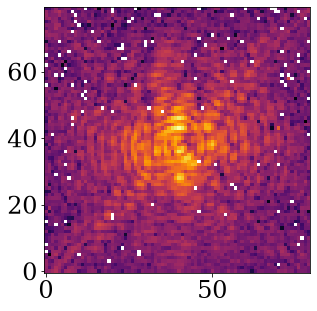

In [8]:
plt.imshow(exposures_single[0].data**0.125)

In [9]:
exposures_single[0].target

'HBC250'

In [10]:
params = {
    "spectrum": {},
    "primary_opd": {},
    "primary_low": {},
    "primary_tilt": {},
    "cold_mask_opd": {},
    "cold_mask_tilt": {},
    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_shear": {},
    "cold_mask_scale": {},

    "bias": {},
    "occulter_radius": 0.76,
    "occulter_coeffs": np.zeros(2)+1e-3,
    "fnumber": 45.3,
    "resolved": {},
}


for idx, exp in enumerate(exposures_single):
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels)*6)

    params["primary_tilt"][exp.fit.get_key(exp, "primary_tilt")] = np.array([0.00, 0.])
    params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([-0., -0.])

    params["primary_opd"][exp.fit.get_key(exp, "primary_opd")] = np.zeros((n_modes, n_modes))
    params["primary_low"][exp.fit.get_key(exp, "primary_low")] = np.zeros((n_zernikes))
    params["cold_mask_opd"][exp.fit.get_key(exp, "cold_mask_opd")] = np.array([120.])

    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([13.,7.])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = 0.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.

    params["resolved"][exp.fit.get_key(exp, "resolved")] = np.zeros((resolved_wid,resolved_wid))#+1.5#.at[:3, :3].set(3.)-2
    


    # params["quadrature"][exp.fit.get_key(exp, "quadrature")] = np.array(0.)


model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))
#model_binary = set_array(NICMOSModel(exposures_binary, params, optics, detector))


params = ModelParams(params)

5.877406529598673
6.290784194523871


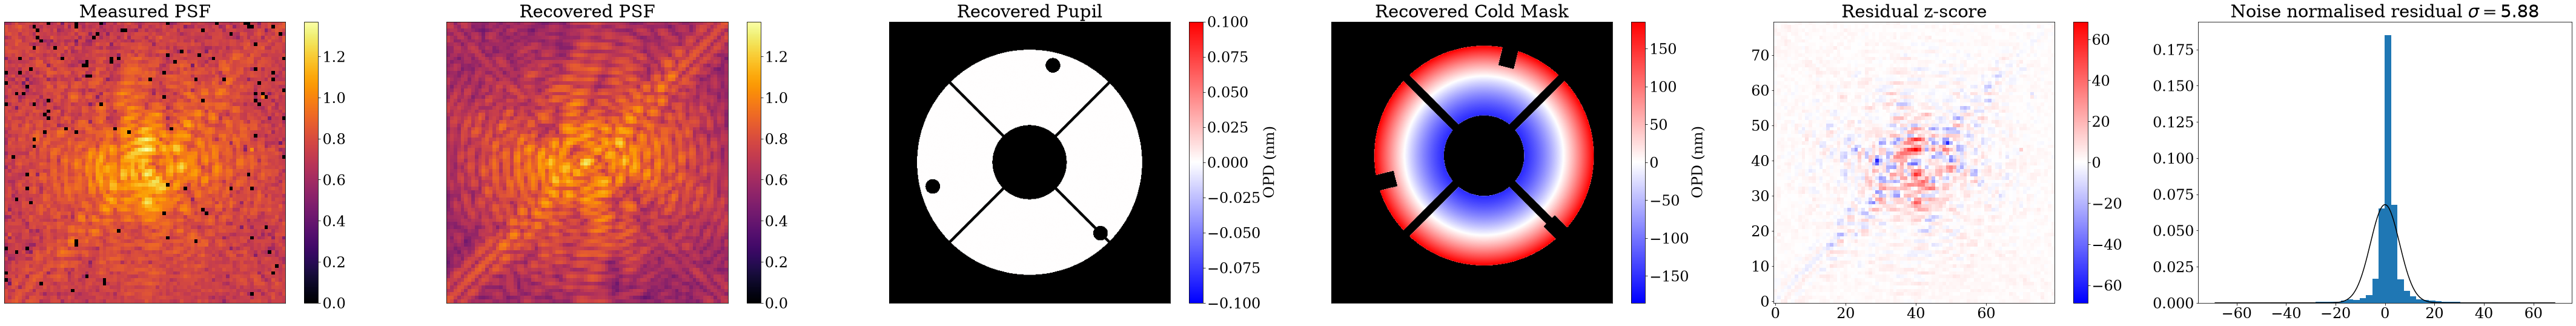

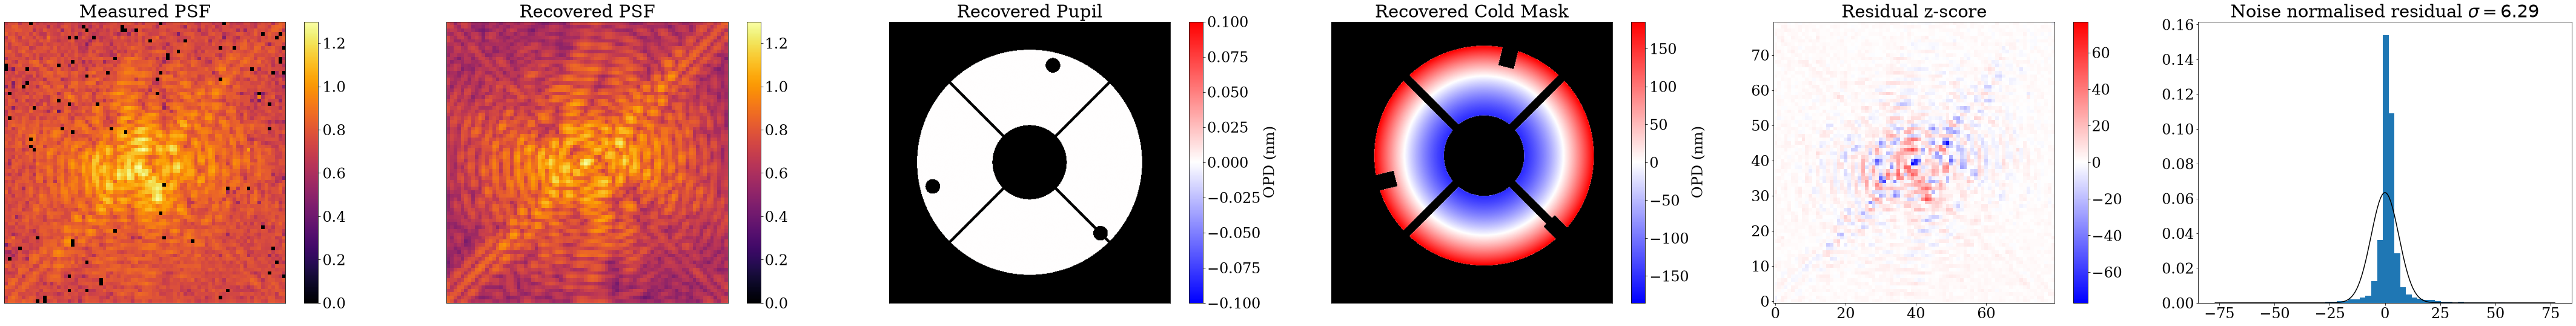

In [11]:
plot_comparison(model_single, params, exposures_single)

In [12]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)

def adam(lr, delay):
    return optax.adam(zdx.optimisation.delay(lr, delay))


g = 5e-2

"""
    "spectrum": sgd(g*3, 0),
    "cold_mask_shift": sgd(g*20, 40),
    
    "bias": sgd(g*3, 20),
    "primary_opd": sgd(g*0.1, 10),
    # "primary_opd": adam(0.1, 10),

    "cold_mask_opd": sgd(g*3, 10),

    "primary_tilt": sgd(g*1, 10),
    "cold_mask_tilt": sgd(g*1, 10),
    #"jitter": opt(g*1, 120),


    "cold_mask_shear": sgd(g*2, 200),
    "cold_mask_rot": sgd(g*3, 200),
    "cold_mask_scale": sgd(g*15, 200),

    # "quadrature": sgd(g*20, 400)

    "occulter_radius": sgd(g*10, 200),
    "fnumber": sgd(g*0.05, 220),

    "occulter_coeffs": sgd(g*20, 300),
"""

things = {
    "spectrum": sgd(g*3, 0),
    "primary_opd": sgd(g*0.1, 20),
    "primary_low": sgd(g*0.1, 10),
    "primary_tilt": sgd(g*1., 10),
    "cold_mask_tilt": sgd(g*1, 10),
    "cold_mask_opd": sgd(g*1, 10),

    "bias": sgd(g*3, 50),
    "cold_mask_shift": sgd(g*5, 60),

    # "cold_mask_shear": sgd(g*2, 200),
    # "cold_mask_rot": sgd(g*3, 200),
    # "cold_mask_scale": sgd(g*15, 200),

    # # "quadrature": sgd(g*20, 400)

    "occulter_radius": sgd(g*10, 200),
    "occulter_coeffs": sgd(g*10, 200),
    "fnumber": sgd(g*0.5, 220),

    # "resolved": adam(3e-2, 200)
}

things_start = {
    "positions": sgd(g*5, 0),
}

groups = list(things.keys())

In [13]:
# orig_params = params.params
# opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [14]:
# losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_start, 10)

In [15]:
# plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single)

In [16]:
orig_params = params.params #| params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [17]:
# losses, params_history = optimise_new_resolved(opt_params, model_single, exposures_single, things, 300, nbatches=10)
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things, 500, nbatches=5)

  0%|          | 0/500 [00:00<?, ?it/s]

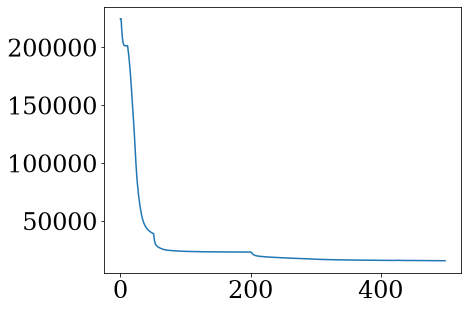

In [18]:
plt.plot(losses[:])

In [19]:
losses[-1]

Array(15747.00386543, dtype=float64)

11
2.6971021288554877
2.3360203987765873


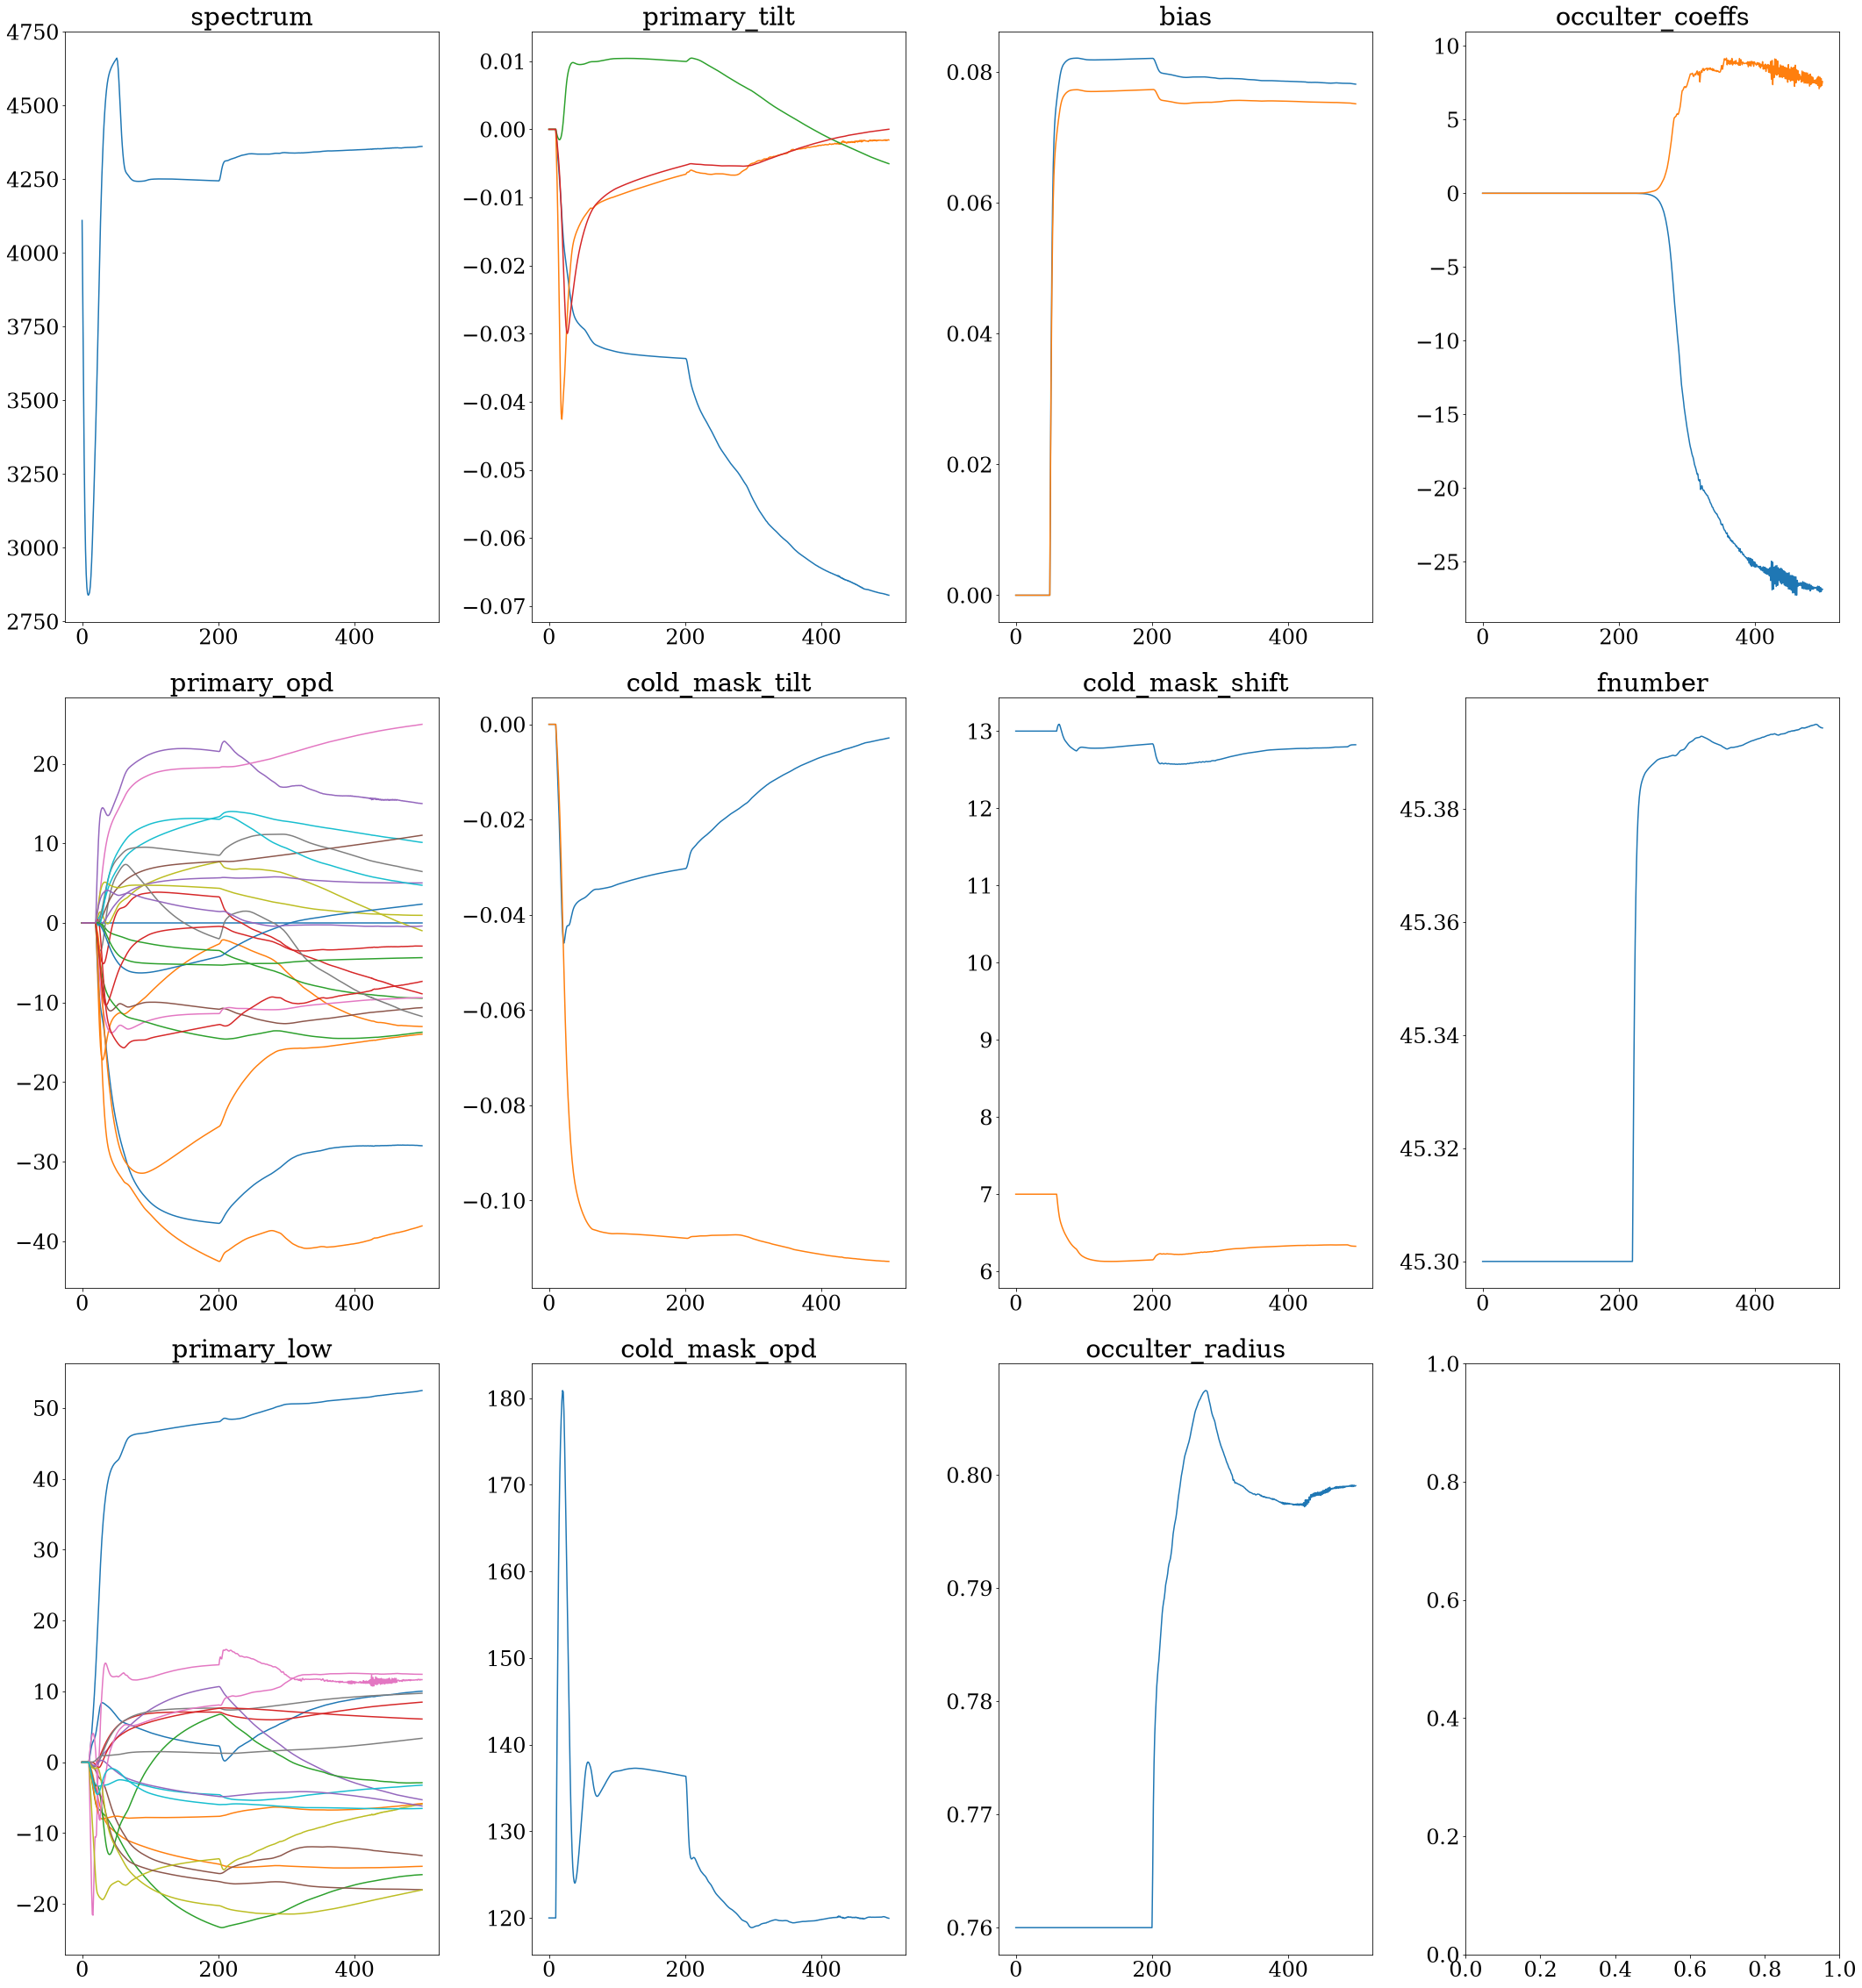

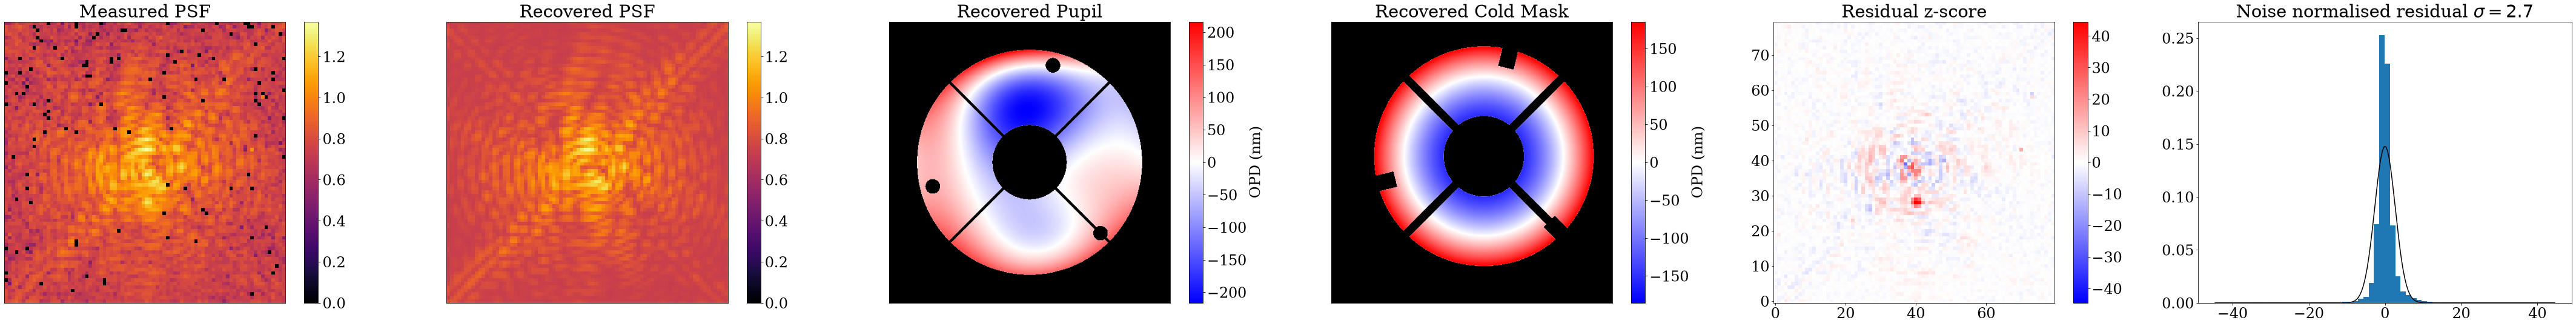

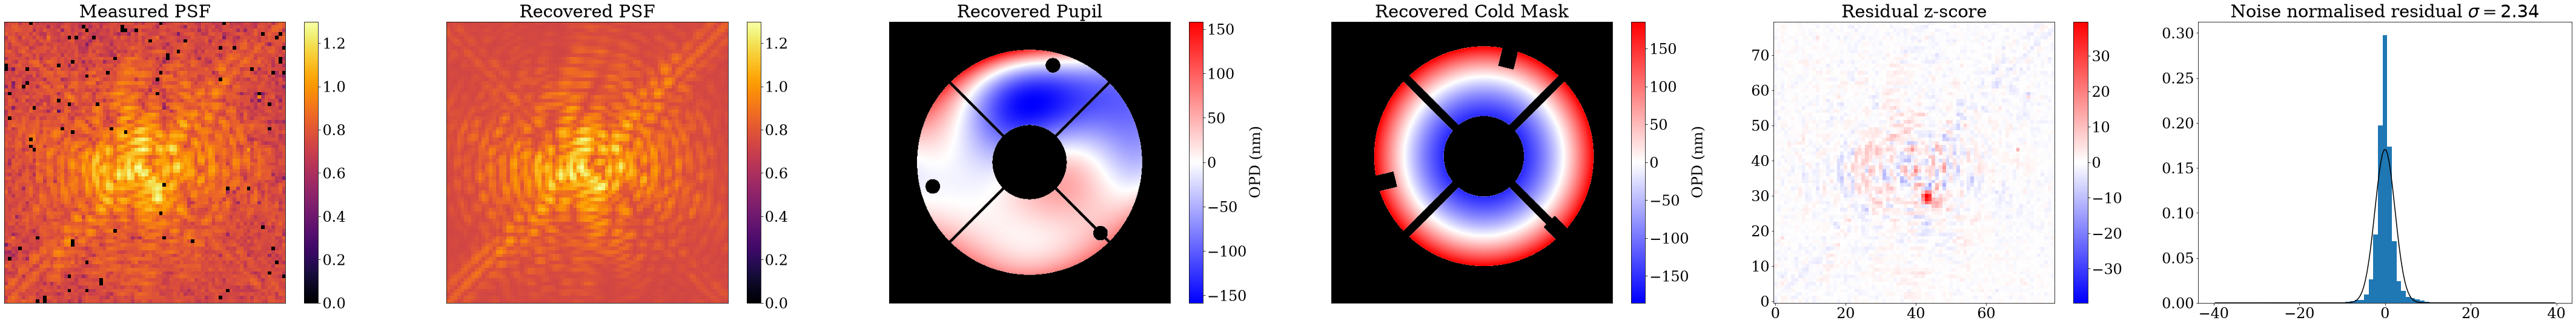

In [20]:
plot_params(params_history, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=False)

In [21]:
params_history[-1]

{'bias': {'n8qn20srq': Array(0.07813785, dtype=float64),
  'n8qn21t6q': Array(0.07513601, dtype=float64)},
 'cold_mask_opd': {'global': Array([119.95890605], dtype=float64)},
 'cold_mask_shift': {'global': Array([12.82351579,  6.32537805], dtype=float64)},
 'cold_mask_tilt': {'global': Array([-0.00286231, -0.11277426], dtype=float64)},
 'fnumber': Array(45.39433156, dtype=float64),
 'occulter_coeffs': Array([-26.85739494,   7.57625486], dtype=float64),
 'occulter_radius': Array(0.79904352, dtype=float64),
 'primary_low': {'n8qn20srq': Array([ 10.02048537, -14.70119906, -15.87309047,   8.47508874,
          -5.30241693, -13.19569746,  11.65335758,   9.72931531,
          -5.92202152,  -3.24022037], dtype=float64),
  'n8qn21t6q': Array([ 52.46486661,  -5.8349452 ,  -2.89995107,   6.09280933,
          -6.17963317, -18.00787744,  12.40529764,   3.3735001 ,
         -18.03513086,  -6.53279856], dtype=float64)},
 'primary_opd': {'global': Array([[  0.        , -13.02095618,  -9.47332823,  -

In [ ]:
plt.imshow((params_history[-1]["resolved"]["HBC250_F190N"]))  
plt.colorbar()

KeyError: 'resolved'